In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str

In [3]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    state['strike_rate'] = (state['runs'] / state['balls']) * 100
    return state

In [13]:
def calculate_balls_per_boundary(state: BatsmanState):
    total_boundaries = state['fours'] + state['sixes']
    state['balls_per_boundary'] = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {'balls_per_boundary': state['balls_per_boundary']}

In [14]:
def calculate_boundary_percentage(state: BatsmanState):
    total_boundaries_runs = state['fours'] * 4 + state['sixes'] * 6
    state['boundary_percentage'] = (total_boundaries_runs / state['balls']) * 100 if state['balls'] > 0 else 0.0
    return {'boundary_percentage': state['boundary_percentage']}

In [15]:
def create_summary(state: BatsmanState):
    state['summary'] = f"""Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}
        Strike Rate: {state['strike_rate']:.2f}, Balls per Boundary: {state['balls_per_boundary']:.2f},
        Boundary Percentage: {state['boundary_percentage']:.2f}%"""
    return {'summary': state['summary']}

## In above node functions updates are done partially to state and only the variable that has been updated is sent to next node to avoid conflict

In [16]:
graph = StateGraph(BatsmanState)

graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("create_summary", create_summary)

In [17]:
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_strike_rate", "create_summary")
graph.add_edge("calculate_balls_per_boundary", "create_summary")
graph.add_edge("calculate_boundary_percentage", "create_summary")

graph.add_edge("create_summary", END)

In [18]:
workflow = graph.compile()

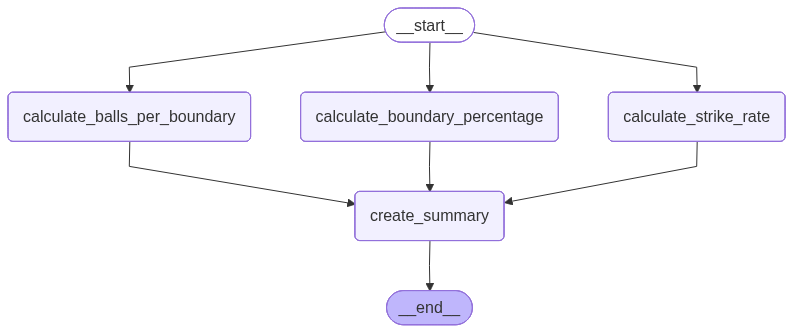

In [19]:
workflow

In [20]:
initial_state = {
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'balls_per_boundary': 5.0,
 'boundary_percentage': 96.0,
 'summary': 'Runs: 100, Balls: 50, Fours: 6, Sixes: 4\n        Strike Rate: 200.00, Balls per Boundary: 5.00,\n        Boundary Percentage: 96.00%'}